**Diana Itzel Soto Castañeda**

**Ciencia de Datos para Sensores Inteligentes**

# Imports

In [70]:
# system libraries
import os
import sys

print("Python:", sys.version)
print("Executable:", sys.executable)

Python: 3.9.25 (main, Nov  3 2025, 22:44:01) [MSC v.1929 64 bit (AMD64)]
Executable: c:\Users\Diana\git\Course_CDSI_2026\practicas\PR3_Inercial\.venv\python.exe


In [71]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1.- Recolección de datos

Se recolectaron datos de tiros de baloncesto. Para ello se emplearon tres sensores IMU (*Inertial Measurement Unit*) modelo LPMS-B2 Series. En la prueba participarón ocho sujetos, cada uno tiro tantos tiros como necesitará antes de encestar tres o acompletar veinte tiros. Para cada tiro se etiqueto el éxito o fallo del tiro. Los sensores se calibrarón antes de iniciar la grabación con los brazos abajo.

Cabe resaltar que durante la recolección de los datos se detectarón múltiples fallas de pérdida de conexión con los sensores, por lo cuál no se cuenta con datos completos para cada tiro, como se había determinado. Además de que los datos de tiro exitoso fueron escasos en comparación con los datos de falla.

## Carga de datos

In [72]:
project_root = Path(".")
data_trial_dir = project_root / "data"
labels_path = data_trial_dir / "labels_PR3.csv"

data_test_dir = project_root / "data" / "test"

labels = pd.read_csv(labels_path)

# Cargar todos los archivos de datos de prueba
df_trial = {}
for idx, row in labels.iterrows():
    file_name = row["Nombre Archivo"]
    file_path = data_trial_dir / file_name

    print(file_path)
    
    if file_path.exists():
        try:
            df_trial[file_name] = pd.read_csv(file_path)
        except pd.errors.EmptyDataError:
            print(f"Archivo vacío: {file_path}")
        except Exception as e:
            print(f"Error al leer {file_name}: {e}")
    else:
        print(f"Archivo no encontrado: {file_path}")

print(f"Se cargaron {len(df_trial)} archivos de datos de prueba")
print(f"Archivos cargados: {list(df_trial.keys())[:5]}...")  # Mostrar primeros 5

# Cargar todos los archivos de datos de prueba
df_test = {}
for file_path in data_test_dir.glob("*.csv"):
    file_name = file_path.name
    
    try:
        df_test[file_name] = pd.read_csv(file_path)
    except pd.errors.EmptyDataError:
        print(f"Archivo vacío: {file_path}")
    except Exception as e:
        print(f"Error al leer {file_name}: {e}")

print(f"\nSe cargaron {len(df_test)} archivos de datos de validación")
print(f"Archivos cargados: {list(df_test.keys())[:5]}...")  # Mostrar primeros 5

# Limpiar nombres de columnas (eliminar espacios en blanco)
for name, df in df_trial.items():
    df.columns = df.columns.str.strip()

for name, df in df_test.items():
    df.columns = df.columns.str.strip()

data\Mariel_01.csv
data\Mariel_02.csv
data\Mariel_03.csv
data\Mariel_04.csv
data\Mariel_05.csv
data\Mariel_06.csv
data\Mariel_07.csv
data\Mariel_08.csv
data\Mariel_09.csv
data\Mariel_10.csv
data\Mariel_11.csv
data\Mariel_12.csv
data\Mariel_13.csv
data\Mariel_14.csv
data\Mariel_15.csv
data\Mariel_16.csv
data\Mariel_17.csv
data\Erick_01.csv
data\Erick_02.csv
data\Erick_03.csv
data\Erick_04.csv
data\Erick_05.csv
data\Erick_06.csv
data\Erick_07.csv
data\Erick_08.csv
data\Erick_09.csv
data\Erick_10.csv
data\Erick_11.csv
data\Erick_12.csv
data\Erick_13.csv
data\Juliet_01.csv
data\Juliet_02.csv
data\Juliet_03.csv
data\Juliet_04.csv
data\Juliet_05.csv
data\Juliet_06.csv
data\Juliet_07.csv
data\Juliet_08.csv
data\Juliet_09.csv
data\Juliet_10.csv
data\Juliet_11.csv
data\Juliet_12.csv
data\Juliet_13.csv
data\Juliet_14.csv
data\Juliet_15.csv
data\Juliet_16.csv
data\Juliet_17.csv
data\Juliet_18.csv
data\Ian_01.csv
data\Ian_02.csv
data\Ian_03.csv
data\Ian_04.csv
data\Ian_05.csv
data\Ian_06.csv
data\

## Exploración de datos

Durante la práctica se detectarón inconsistencias en el sensado, por lo cuál se pone especial atención a la exploración de datos, para notar la naturaleza del dataset y poder definir la estrategia correcta.

In [73]:
ejemplo = df_trial["Mariel_01.csv"]

print(ejemplo.shape)
ejemplo.head()


(1237, 26)


,SensorId,TimeStamp (s),FrameNumber,AccX (g),AccY (g),AccZ (g),GyroX (deg/s),GyroY (deg/s),GyroZ (deg/s),MagX (uT),...,QuatX,QuatY,QuatZ,LinAccX (g),LinAccY (g),LinAccZ (g),Pressure (kPa),Altitude (m),Temperature (degC),HeaveMotion (m)
0,4,0.00,0,0.231569,1.055345,-0.527586,118.630119,67.750877,230.197601,-34.463608,...,0.0,0.0,0.0,-0.169744,0.316244,0.084618,101.521004,-16.303003,39.259998,0.0
1,4,0.01,1,0.221655,1.130493,-0.543380,138.806961,93.046181,247.326752,-34.463608,...,0.0,0.0,0.0,-0.156804,0.242307,0.182916,101.521004,-16.303003,39.259998,0.0
2,4,0.02,2,0.247653,1.206001,-0.509299,152.695618,117.486176,263.231750,-32.680504,...,0.0,0.0,0.0,-0.169828,0.169825,0.262196,101.521004,-16.303003,39.259998,0.0
3,4,0.03,3,0.340247,1.251817,-0.538926,155.860092,134.517548,278.394135,-30.575855,...,0.0,0.0,0.0,-0.235281,0.166003,0.303686,101.521004,-16.303003,39.259998,0.0
4,4,0.04,4,0.420237,1.325874,-0.609399,150.306763,141.356750,294.569763,-28.237358,...,0.0,0.0,0.0,-0.303912,0.198198,0.387920,101.521004,-16.303003,39.259998,0.0


In [74]:
ejemplo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1237 entries, 0 to 1236
Data columns (total 26 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   SensorId            1237 non-null   int64  
 1   TimeStamp (s)       1237 non-null   float64
 2   FrameNumber         1237 non-null   int64  
 3   AccX (g)            1237 non-null   float64
 4   AccY (g)            1237 non-null   float64
 5   AccZ (g)            1237 non-null   float64
 6   GyroX (deg/s)       1237 non-null   float64
 7   GyroY (deg/s)       1237 non-null   float64
 8   GyroZ (deg/s)       1237 non-null   float64
 9   MagX (uT)           1237 non-null   float64
 10  MagY (uT)           1237 non-null   float64
 11  MagZ (uT)           1237 non-null   float64
 12  EulerX (deg)        1237 non-null   float64
 13  EulerY (deg)        1237 non-null   float64
 14  EulerZ (deg)        1237 non-null   float64
 15  QuatW               1237 non-null   float64
 16  QuatX 

Dado que se sabe que se perdió conexión con los sensores durante la grabación de algunos tiros, y además se sospecha de que el ID de los sensores pudo haber cambiado durante la grabación se explora el ID de todos las grabaciones:

In [75]:
for name, df in list(df_trial.items()):
    print(name, df["SensorId"].unique())

Mariel_01.csv [4 2 5]
Mariel_02.csv [4 2 5]
Mariel_03.csv [5 4 2]
Mariel_04.csv [4 2 5]
Mariel_05.csv [4 5 2]
Mariel_06.csv [4 2 5]
Mariel_07.csv [2 4 5]
Mariel_08.csv [4 5 2]
Mariel_09.csv [5 4 2]
Mariel_10.csv [5 4 2]
Mariel_11.csv [4 5 2]
Mariel_12.csv [2 5 4]
Mariel_13.csv [2 5]
Mariel_14.csv [5 2]
Mariel_15.csv [5 2 4]
Mariel_16.csv [2 5]
Mariel_17.csv [5 2 4]
Erick_01.csv [2 5 4]
Erick_02.csv [5 4 2]
Erick_03.csv [5 2]
Erick_04.csv [2 4 5]
Erick_05.csv [2 5]
Erick_06.csv [4 2 5]
Erick_07.csv [5 2]
Erick_08.csv [5 2]
Erick_09.csv [5 2]
Erick_10.csv [5 2]
Erick_11.csv [2 5]
Erick_12.csv [5 2]
Erick_13.csv [5 2]
Juliet_01.csv [5 2]
Juliet_02.csv [5 2]
Juliet_03.csv [2 5]
Juliet_04.csv [2 5]
Juliet_05.csv []
Juliet_06.csv [2 5]
Juliet_07.csv [5 2]
Juliet_08.csv [5 2]
Juliet_09.csv [2 5]
Juliet_10.csv [2 5]
Juliet_11.csv [2 5]
Juliet_12.csv [5 2]
Juliet_13.csv [5 2]
Juliet_14.csv [5 2]
Juliet_15.csv [2 5]
Juliet_16.csv [2 5]
Juliet_17.csv [2 5]
Juliet_18.csv [5 2]
Ian_01.csv [2 5]
Ian

In [76]:
for name, df in list(df_test.items()):
    print(name, df["SensorId"].unique())

Joan_01.csv [5]
Joan_02.csv [2 4 5]
Joan_03.csv [2 5 4]
Joan_04.csv [5]
Joan_05.csv [5 4]
Joan_06.csv [5 4]
Joan_07.csv [5]
Joan_08.csv [2 4 5]
Joan_09.csv [5 2]
Joan_10.csv [5]
Joan_11.csv [5 4]
Joan_12.csv [5]
Joan_13.csv [5 4]
Joan_14.csv [5 2 4]
Joan_15.csv [5 4]
Joan_16.csv [5]
Joan_17.csv [5]
Joan_18.csv [5 2]
Joan_19.csv [5 2 4]
Joan_20.csv [5]
Tony_01.csv [1 5 2]
Tony_02.csv [1 5 2]
Tony_03.csv [2 3]
Tony_04.csv [1 2 5]
Tony_05.csv [3 2 1]
Tony_06.csv [1 2 5]
Tony_07.csv [2 3]
Tony_08.csv [2 3]
Tony_09.csv [1 5 2]
Tony_10.csv [1 5 2]


Se confirma que los ID's se mantuvieron, para el set de prueba. Pero no así para el test de validación.

**Más adelante, trataré de diferenciar los sensores por la energía promedio de la señal temporal.**

Verificar si existen archivos vacíos:


In [77]:
for name, df in df_trial.items():
    if df.empty:
        empty_file = name

df_trial[empty_file].shape

(0, 26)

Dado que el archivo está vació y puede insertar ruido, lo eliminaré del conjunto de prueba:

In [78]:
df_trial = {k: v for k, v in df_trial.items() if not v.empty}

df_test = {k: v for k, v in df_test.items() if not v.empty}

In [79]:
print(empty_file in df_trial)
print(f"Total archivos ahora: {len(df_trial)}")

print(f"Total archivos test ahora: {len(df_test)}")

False
Total archivos ahora: 111
Total archivos test ahora: 30


En el test no existían archivos vacíos.

Verificando sinconización de los sensores y consistencia de datos en los datos:

In [80]:
def analyze_trial_data(df, file_name=""):
    """
    Analiza la sincronización y consistencia de datos de un tiro.
    
    Parameters:
    - df: DataFrame con los datos del tiro
    - file_name: nombre del archivo (opcional, para identificación)
    """
    if file_name:
        print(f"\n=== Análisis de {file_name} ===")
    
    # Verificar cantidad de muestras por sensor
    print("Muestras por sensor:")
    for sid in [2, 4, 5]:
        count = (df["SensorId"] == sid).shape
        print(f"  Sensor {sid}: {(df[df['SensorId'] == sid].shape[0])} muestras")
    

    # Verificar el tiempo de muestreo
    print("\nIntervalo de muestreo promedio:", df["TimeStamp (s)"].diff().mean(), "segundos")
    print("Mediana del intervalo de muestreo:", df["TimeStamp (s)"].diff().median(), "segundos")
# Ejemplo con Mariel_01.csv
analyze_trial_data(df_trial["Mariel_01.csv"], "Mariel_01.csv")


=== Análisis de Mariel_01.csv ===
Muestras por sensor:
  Sensor 2: 405 muestras
  Sensor 4: 426 muestras
  Sensor 5: 406 muestras

Intervalo de muestreo promedio: 0.003406148867313916 segundos
Mediana del intervalo de muestreo: 0.010000000000000009 segundos


In [81]:
analyze_trial_data(df_trial["Zarif_04.csv"], "Zarif_04.csv")


=== Análisis de Zarif_04.csv ===
Muestras por sensor:
  Sensor 2: 0 muestras
  Sensor 4: 0 muestras
  Sensor 5: 202 muestras

Intervalo de muestreo promedio: 0.009999999999999998 segundos
Mediana del intervalo de muestreo: 0.010000000000000009 segundos


In [82]:
analyze_trial_data(df_trial["Norman_02.csv"], "Norman_02.csv")


=== Análisis de Norman_02.csv ===
Muestras por sensor:
  Sensor 2: 194 muestras
  Sensor 4: 382 muestras
  Sensor 5: 0 muestras

Intervalo de muestreo promedio: 0.0034608695652173912 segundos
Mediana del intervalo de muestreo: 0.0025000000000000022 segundos


In [83]:
ejemplo = df_test["Tony_02.csv"]
ejemplo.columns = ejemplo.columns.str.strip()

for sid in [2,4,5]:
    print(sid, ejemplo[ejemplo["SensorId"] == sid].shape)

print(ejemplo["TimeStamp (s)"].diff().mean())    
print(ejemplo["TimeStamp (s)"])

2 (181, 26)
4 (0, 26)
5 (154, 26)
0.00281234375
0      0.0000
1      0.0525
2      0.0550
3     -0.0002
4      0.0575
        ...  
636    1.8825
637    1.8850
638    1.8875
639    1.7899
640    1.7999
Name: TimeStamp (s), Length: 641, dtype: float64


Al notar inconsistencias en la media de los tiempos de muestreo y verificar el TimeStamp para algunos ejemplos, note algunas inconsistencias. Como tiempos negativos y desordenados, posiblemente al envío de paquetes de datos de Bluetooth.

En esta exploración inicial detecte una serie de problemas con el conjunto de datos, tanto de entrenamiento como de prueba:
- Los sensores vienen mezclados.
- Los timestamps vienen desordenados.
- Cabe la posibilidad de que algunos sensores tengan frecuencia de muestreo distinta (como lo refleja el cáclulo de la mediana en "Norman_02")
- Los IDs no son confiables entre entrenamiento y prueba.

Además también sabemos que:
- Hay ruido después del tiro

Cabe mencionar que los conjuntos no están balanceados (muchos tiros, pero pocos se encestarón)

## Curandería de Datos

Para cada archivo voy a:
- Separar por SensorId
- Ordenar por TimeStamp dentro de cada sensor
- Resetear índice
- Normalizar tiempo

In [84]:
def separar_y_ordenar_sensor(df_dict):
    data_procesada = {}

    for nombre_archivo, df in df_dict.items():
        
        sensores_archivo = {}
        
        for sid in df["SensorId"].unique():
            df_s = df[df["SensorId"] == sid].copy()
            
            # Ordenar por tiempo
            df_s = df_s.sort_values("TimeStamp (s)").reset_index(drop=True)
            
            # Normalizar tiempo
            df_s["TimeStamp (s)"] -= df_s["TimeStamp (s)"].iloc[0]
            
            sensores_archivo[sid] = df_s
        
        data_procesada[nombre_archivo] = sensores_archivo

    return data_procesada

In [85]:
train_separado = separar_y_ordenar_sensor(df_trial)
test_separado = separar_y_ordenar_sensor(df_test)

In [86]:
train_separado["Mariel_01.csv"][2].head()

,SensorId,TimeStamp (s),FrameNumber,AccX (g),AccY (g),AccZ (g),GyroX (deg/s),GyroY (deg/s),GyroZ (deg/s),MagX (uT),...,QuatX,QuatY,QuatZ,LinAccX (g),LinAccY (g),LinAccZ (g),Pressure (kPa),Altitude (m),Temperature (degC),HeaveMotion (m)
0,2,0.00,0,1.548234,0.680179,0.155060,4.571787,27.304354,597.479065,15.755627,...,-0.264895,-0.773992,0.511088,-0.849520,0.986105,0.902936,0.0,0.0,0.0,0.0
1,2,0.01,1,1.072523,0.639826,0.141463,2.103586,25.211040,565.899109,11.312482,...,-0.254821,-0.791215,0.511170,-0.445160,1.017265,0.916238,0.0,0.0,0.0,0.0
2,2,0.02,2,0.809843,0.520414,-0.066423,4.482324,39.270634,523.463745,7.190880,...,-0.243712,-0.805355,0.510778,-0.253207,1.128246,0.727313,0.0,0.0,0.0,0.0
3,2,0.03,3,0.747155,0.367816,-0.254953,9.078180,54.299671,469.410889,7.190880,...,-0.231839,-0.816453,0.510369,-0.259357,1.195453,0.515798,0.0,0.0,0.0,0.0
4,2,0.04,4,0.717144,0.255300,-0.326566,11.786459,62.251724,416.553406,3.127740,...,-0.297388,-0.805032,0.482446,-0.252224,1.167943,0.408870,0.0,0.0,0.0,0.0


In [87]:
archivo = list(train_separado.keys())[0]
sensor  = list(train_separado[archivo].keys())[0]

train_separado[archivo][sensor]["TimeStamp (s)"].head()
train_separado[archivo][sensor]["TimeStamp (s)"].tail()

421    4.23
422    4.24
423    4.25
424    4.26
425    4.27
Name: TimeStamp (s), dtype: float64

Gráfiquemos la magnitud de la aceleración para un tiro

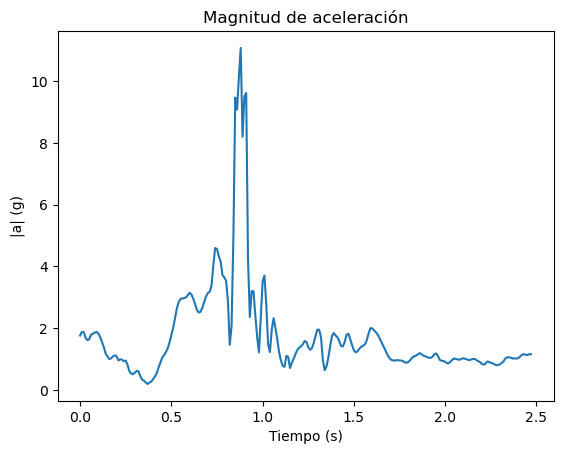

In [106]:
df_s = train_separado["Mariel_03.csv"][2]

acc_mag = np.sqrt(
    df_s["AccX (g)"]**2 +
    df_s["AccY (g)"]**2 +
    df_s["AccZ (g)"]**2
)

plt.plot(df_s["TimeStamp (s)"], acc_mag)
plt.title("Magnitud de aceleración")
plt.xlabel("Tiempo (s)")
plt.ylabel("|a| (g)")
plt.show()

Ahora que se ha organizado el tiempo, quiero asegurarme de que el muestreo se haya hecho a 100 Hz, dado que en la exploración el dato de "Norman_02" generó dudas, que posiblemente fueron solo causadas por el desorden de los datos.

In [89]:
len(df_s)
print("Duración:", df_s["TimeStamp (s)"].iloc[-1])
print("Muestras:", len(df_s))
print("Estimado Hz:", len(df_s) / df_s["TimeStamp (s)"].iloc[-1])

Duración: 1.99
Muestras: 194
Estimado Hz: 97.48743718592965


Se confirma el muestreado de los datos a 100 Hz

## Evento de tiro

A continuación exploraremos el evento de tiro usando el pico de la magnitud de la aceleración. La exploración se hace con el fin de definir la mejor técnica de segmentacion:

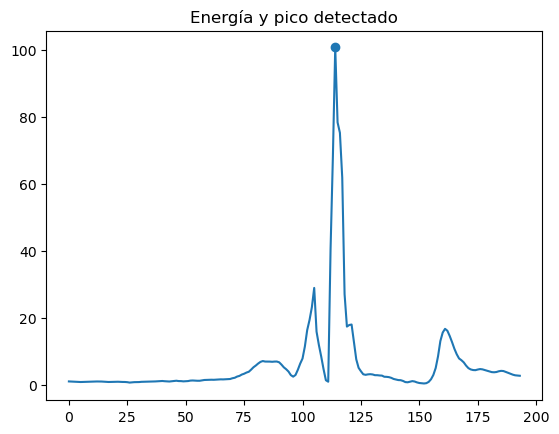

In [90]:
energy = acc_mag**2
idx_peak = energy.idxmax()
plt.figure()
plt.plot(energy)
plt.scatter(idx_peak, energy.iloc[idx_peak])
plt.title("Energía y pico detectado")
plt.show()

Observamos un evento del tiro delimitado mediante una ventana temporal. La ventana se sesg;o hacia la fase preparatoria, tomando aproximadamente 0.6 s previos al pico de energía y 0.3 s posteriores al mismo. El sesgo se tomo porque consideró que la señal biomecanica puede tener información relevante en la preparación del tiro.

In [94]:
pre  = 60
post = 30

start = max(0, idx_peak - pre)
end   = min(len(df_s), idx_peak + post)

df_segment = df_s.iloc[start:end]

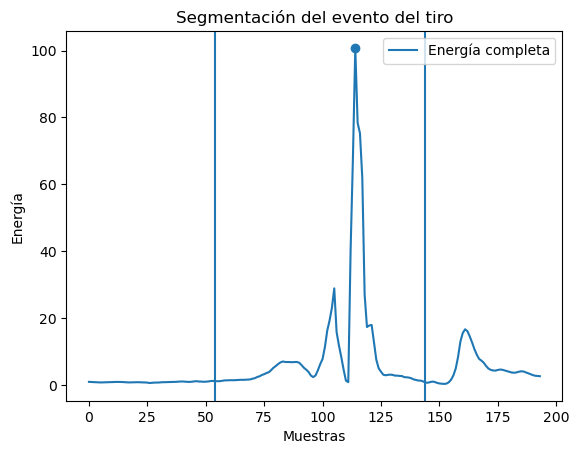

In [96]:


plt.figure()

# Energía completa
plt.plot(energy.values, label="Energía completa")

# Pico
plt.scatter(idx_peak, energy.iloc[idx_peak])

# Límites del segmento
plt.axvline(start)
plt.axvline(end)

plt.title("Segmentación del evento del tiro")
plt.xlabel("Muestras")
plt.ylabel("Energía")
plt.legend()
plt.show()